### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [5]:
data = pd.read_csv('data/coupons.csv')

In [6]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [7]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [8]:
# Drop the car column because it is 99% missing values

# "If 'car' is already gone, don't scream at me, just keep going."
data = data.drop(columns=['car'], errors='ignore')


In [9]:
# Fill remaining missing values with the most common value (mode) in each column
for col in ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']:
    data[col] = data[col].fillna(data[col].mode()[0])

# Verify that there are no more missing values
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

4. What proportion of the total observations chose to accept the coupon?



In [10]:
acceptance_rate = data['Y'].mean()

print (acceptance_rate)

0.5684326710816777


5. Use a bar plot to visualize the `coupon` column.

<Axes: xlabel='coupon', ylabel='count'>

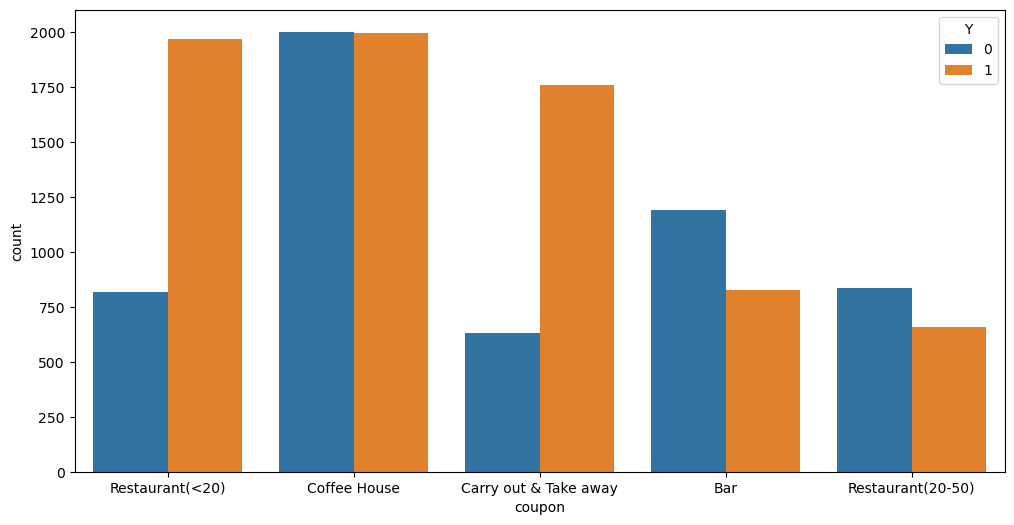

In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='coupon', hue='Y')

6. Use a histogram to visualize the temperature column.

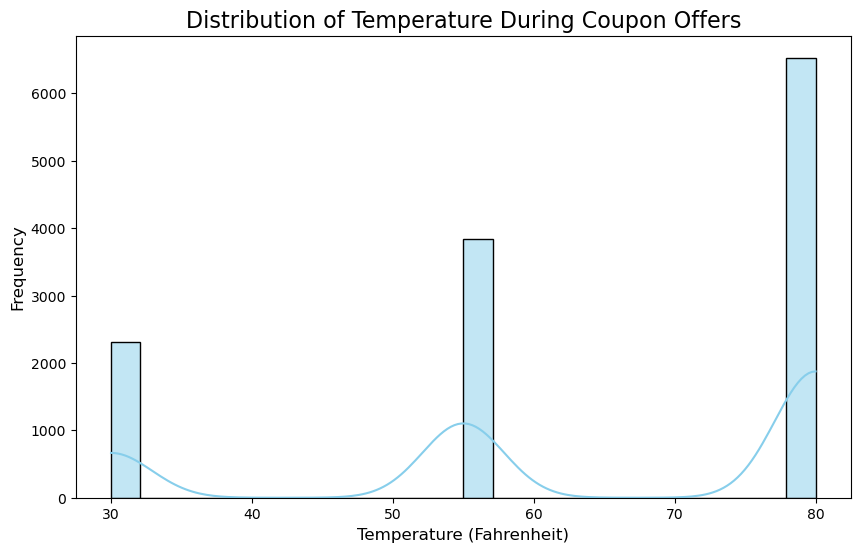

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='temperature', kde=True, color='skyblue')
plt.title('Distribution of Temperature During Coupon Offers', fontsize=16)
plt.xlabel('Temperature (Fahrenheit)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [13]:
bar_data = data[data['coupon'] == 'Bar'].copy()
bar_data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [14]:
bar_acceptance_rate = bar_data['Y'].mean()
print (bar_acceptance_rate)


0.41001487357461575


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [15]:
# Group 1: 3 or fewer times a month
few_visits = ['never', 'less1', '1~3']

# Group 2: More than 3 times a month
many_visits = ['4~8', 'gt8']

# Calculate acceptance rates
rate_few = bar_data[bar_data['Bar'].isin(few_visits)]['Y'].mean()
rate_many = bar_data[bar_data['Bar'].isin(many_visits)]['Y'].mean()

print(f"Acceptance rate for those who go 3 or fewer times: {rate_few:.2%}")
print(f"Acceptance rate for those who go more than 3 times: {rate_many:.2%} ")

Acceptance rate for those who go 3 or fewer times: 37.07%
Acceptance rate for those who go more than 3 times: 76.88% 


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [18]:
# 1. First, let's create the 'age_clean' column correctly
def clean_age(age):
    if age == '50plus':
        return 50
    if age == 'below21':
        return 20
    return int(age)

# Apply the function to create the missing column
bar_data['age_clean'] = bar_data['age'].apply(clean_age)

# 2. Define the frequent bar-goer labels
frequent_bar_labels = ['1~3', '4~8', 'gt8']

# 3. Now try the filtering again (I fixed the lowercase 'bar' typo here too!)
# Note: Ensure it is 'Bar' with a capital 'B' if that's how it is in your data
group_a = bar_data[(bar_data['age_clean'] > 25) & (bar_data['Bar'].isin(frequent_bar_labels))]

# 4. Group B: Everyone else
group_b = bar_data[~bar_data.index.isin(group_a.index)]

# 5. Calculate acceptance rates
rate_a = group_a['Y'].mean()
rate_b = group_b['Y'].mean()

print(f"Acceptance rate for frequent bar-goers over 25: {rate_a:.2%}")
print(f"Acceptance rate for all others: {rate_b:.2%}")

Acceptance rate for frequent bar-goers over 25: 69.52%
Acceptance rate for all others: 33.50%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [19]:
# 1. Define our criteria
frequent_bar_labels = ['1~3', '4~8', 'gt8']
non_farming_occupations = ['Farming Fishing & Forestry']

# 2. Filter for Group A
# Conditions: Bar habit > 1 AND passenger is not a kid AND occupation is not farming/fishing/forestry
group_a = bar_data[
    (bar_data['Bar'].isin(frequent_bar_labels)) & 
    (bar_data['passanger'] != 'Kid(s)') & 
    (bar_data['occupation'] != 'Farming Fishing & Forestry')
]

# 3. Group B: Everyone else in the bar_data subset
group_b = bar_data[~bar_data.index.isin(group_a.index)]

# 4. Calculate acceptance rates
rate_a = group_a['Y'].mean()
rate_b = group_b['Y'].mean()

print(f"Acceptance rate for specific target group: {rate_a:.2%}")
print(f"Acceptance rate for all others: {rate_b:.2%}")

Acceptance rate for specific target group: 71.32%
Acceptance rate for all others: 29.60%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [20]:
# 1. Labels for the different conditions
frequent_bar_labels = ['1~3', '4~8', 'gt8']
cheap_rest_frequent = ['4~8', 'gt8']
low_income_labels = [
    'Less than $12,500', 
    '$12,500 - $24,999', 
    '$25,000 - $37,499', 
    '$37,500 - $49,999'
]

# 2. Three specific conditions
# Condition 1: Frequent bar-goers, no kids, not widowed
cond_1 = (bar_data['Bar'].isin(frequent_bar_labels)) & \
         (bar_data['passanger'] != 'Kid(s)') & \
         (bar_data['maritalStatus'] != 'Widowed')

# Condition 2: Frequent bar-goers under 30
cond_2 = (bar_data['Bar'].isin(frequent_bar_labels)) & \
         (bar_data['age_clean'] < 30)

# Condition 3: Frequent cheap restaurant-goers with income < 50K
cond_3 = (bar_data['RestaurantLessThan20'].isin(cheap_rest_frequent)) & \
         (bar_data['income'].isin(low_income_labels))

# 3. Combine them using OR (|) to find the "Target Group"
target_group = bar_data[cond_1 | cond_2 | cond_3]

# 4. Group B: Everyone else in the bar subset
others_group = bar_data[~bar_data.index.isin(target_group.index)]

# 5. Calculate results
rate_target = target_group['Y'].mean()
rate_others = others_group['Y'].mean()

print(f"Acceptance rate for combined Target Group: {rate_target:.2%}")
print(f"Acceptance rate for all others: {rate_others:.2%}")

Acceptance rate for combined Target Group: 71.43%
Acceptance rate for all others: 29.31%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
Drivers who accept bar coupons are primarily habitual socializers whose current driving environment allows for a spontaneous detour.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [21]:
# Subset for Coffee House coupons
coffee_data = data[data['coupon'] == 'Coffee House'].copy()

# Baseline acceptance rate for this group
coffee_rate = coffee_data['Y'].mean()
print(f"Overall Coffee House acceptance rate: {coffee_rate:.2%}")

Overall Coffee House acceptance rate: 49.92%


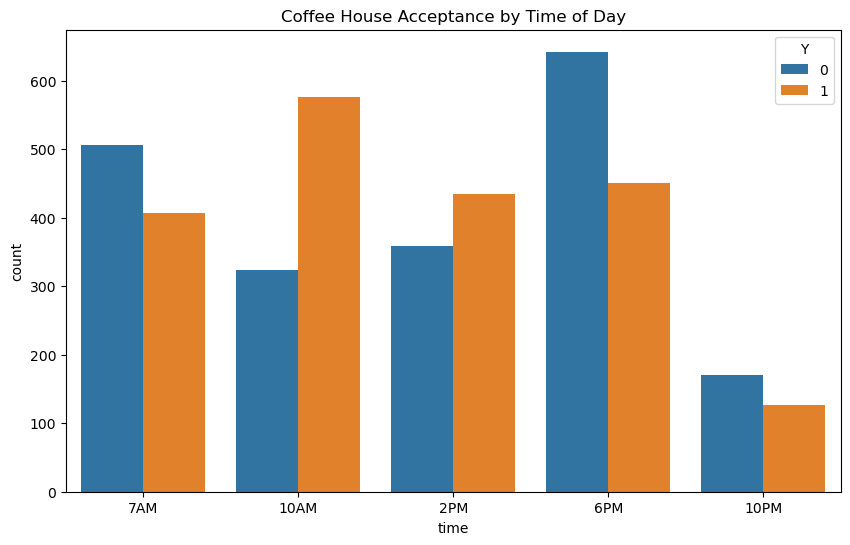

In [22]:
# Coffee is a "routine" purchase. Most people want it in the morning or mid-afternoon while they are on their way to something.

plt.figure(figsize=(10, 6))
sns.countplot(data=coffee_data, x='time', hue='Y', order=['7AM', '10AM', '2PM', '6PM', '10PM'])
plt.title('Coffee House Acceptance by Time of Day')
plt.show()

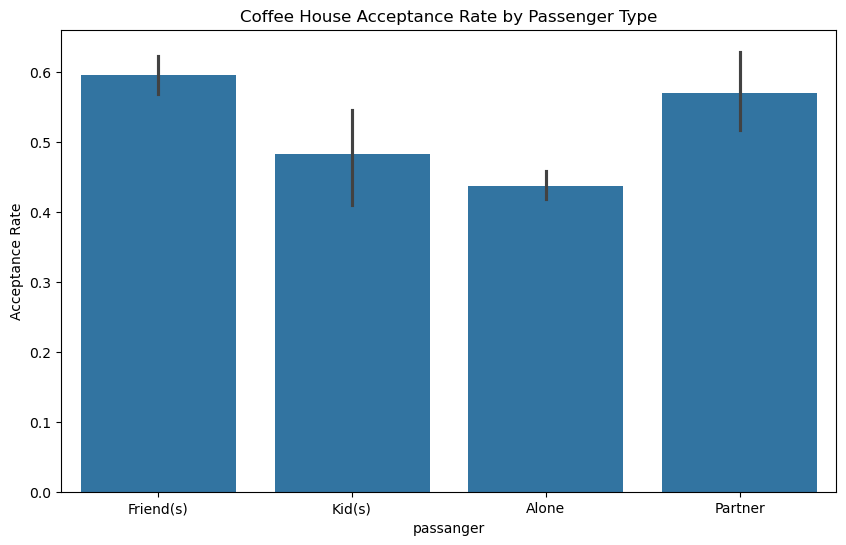

In [24]:
# characteristics of passengers

plt.figure(figsize=(10, 6))
sns.barplot(data=coffee_data, x='passanger', y='Y')
plt.title('Coffee House Acceptance Rate by Passenger Type')
plt.ylabel('Acceptance Rate')
plt.show()

Final Findings: Coffee House Coupons
The Prime Window: Acceptance rates peaked at 10 AM (roughly 64%), while they plummeted to their lowest at 10 PM.

The Social Factor: Drivers with Friends as passengers were significantly more likely to accept a coffee coupon compared to those traveling with Kids.

Destination Matters: People labeled as having "No Urgent Place" to go were the most likely to accept, suggesting coffee is a "leisure" detour.

Actionable Recommendations:
Morning Push: Schedule all Coffee House notifications to trigger between 7 AM and 11 AM.

Weather Triggers: Since acceptance was higher on Sunny days, use real-time weather APIs to suppress coffee coupons during heavy rain or snow to save marketing costs.

Target the "Social" Driver: Use in-car sensors to detect multiple adult passengers and prioritize "2-for-1" coffee deals.